In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/HDFCBANK_features.csv")

In [3]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Price,Close,High,Low,Open,Volume,Daily_Return,SMA_20,SMA_50,EMA_20,RSI,MACD,MACD_Signal,BB_High,BB_Low,ATR
0,50,51,2020-03-12,475.805664,503.152965,467.489675,500.823553,59000770.0,-0.083049,549.972977,569.927427,542.344095,13.654261,-18.161159,-11.730665,599.676216,500.269738,15.888575
1,51,52,2020-03-13,498.401001,503.828485,428.239096,456.588028,66342364.0,0.047489,545.798676,567.981904,538.159038,29.426444,-19.358298,-13.256192,598.037983,493.559368,20.152919
2,52,53,2020-03-16,465.649414,483.120002,463.552943,482.188238,31986322.0,-0.065713,540.163824,565.305410,531.253360,22.897568,-22.688283,-15.142610,600.784354,479.543295,21.202572
3,53,54,2020-03-17,454.281891,470.541197,444.777908,469.609432,42676838.0,-0.024412,534.474239,562.572542,523.922744,21.144062,-25.945500,-17.303188,604.221734,464.726743,21.528337
4,54,55,2020-03-18,408.532318,462.621257,402.988306,458.894198,61181406.0,-0.100707,526.548419,559.180453,512.933180,15.874961,-31.851314,-20.212813,613.574237,439.522602,24.250096


In [4]:
df["Target"] = df["Close"].shift(-1)

In [5]:
df.dropna(inplace=True)

In [6]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "SMA_20",
    "SMA_50",
    "EMA_20",
    "RSI",
    "MACD",
    "MACD_Signal",
    "BB_High",
    "BB_Low",
    "ATR"
]

In [7]:
X = df[features]
y = df["Target"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
print(X_train.shape)
print(X_test.shape)

(1248, 14)
(313, 14)


In [10]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[ 0.23, 0.23, 0.24,...,-0.04, 0. ,-0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['Open','High','Low',...,'BB_High','BB_Low','ATR']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.9788
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [11]:
lr_pred = lr.predict(X_test)

In [12]:
print("Linear Regression")

print("MAE :", mean_absolute_error(y_test, lr_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))

print("R2 :", r2_score(y_test, lr_pred))

Linear Regression
MAE : 8.154038459620859
RMSE : 10.690382093935934
R2 : 0.9924614022332039


In [13]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [14]:
rf_pred = rf.predict(X_test)

In [15]:
print("Random Forest")

print("MAE :", mean_absolute_error(y_test, rf_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 :", r2_score(y_test, rf_pred))

Random Forest
MAE : 7.835387235403826
RMSE : 10.52948817654824
R2 : 0.9926866116084916


In [16]:
from xgboost import XGBRegressor

In [17]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [18]:
print("XGBoost")

print("MAE :", mean_absolute_error(y_test, xgb_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, xgb_pred)))

print("R2 :", r2_score(y_test, xgb_pred))

XGBoost
MAE : 7.931491937119362
RMSE : 10.580311495973586
R2 : 0.9926158412730259


In [19]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]
})

print(results)

               Model       MAE       RMSE        R2
0  Linear Regression  8.154038  10.690382  0.992461
1      Random Forest  7.835387  10.529488  0.992687
2            XGBoost  7.931492  10.580311  0.992616


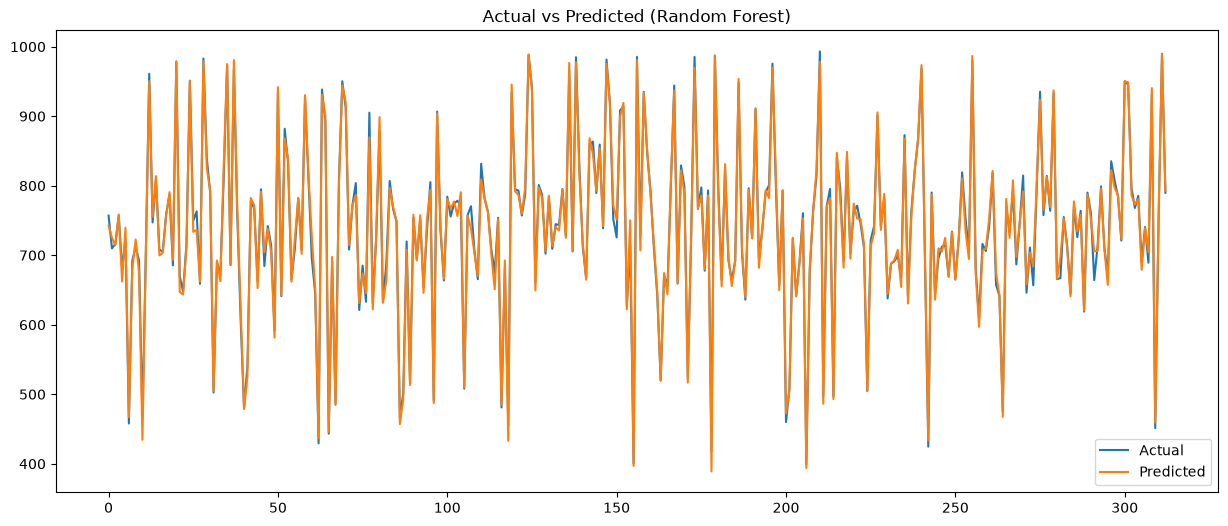

In [20]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values, label="Actual")

plt.plot(rf_pred, label="Predicted")

plt.title("Actual vs Predicted (Random Forest)")

plt.legend()

plt.show()

In [21]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

        Feature  Importance
3         Close    0.663964
1          High    0.114816
2           Low    0.086428
0          Open    0.045093
5        SMA_20    0.041331
7        EMA_20    0.035076
13          ATR    0.006683
12       BB_Low    0.002713
11      BB_High    0.001503
4        Volume    0.000623
8           RSI    0.000542
10  MACD_Signal    0.000535
9          MACD    0.000399
6        SMA_50    0.000295


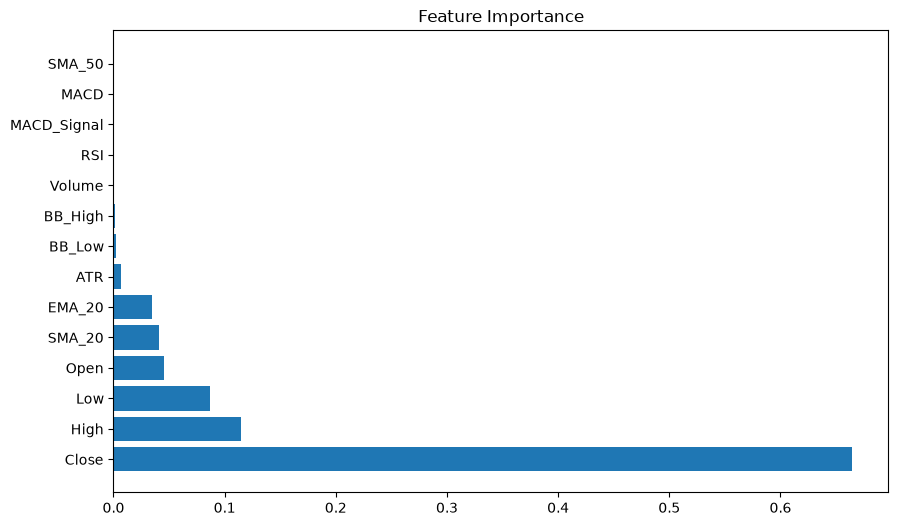

In [22]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.show()

In [23]:
joblib.dump(rf, "../models/random_forest.pkl")

['../models/random_forest.pkl']

In [24]:
model = joblib.load("../models/random_forest.pkl")